In [15]:
# 데이터 처리 및 분석
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import warnings

# 경로 설정
import os 
import sys

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 통계
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12,6)

# 시드 설정
np.random.seed(42)

print('-' * 60)
print('라이브러리 로드 완료')
print('한글 폰트 설정 완료!')
print('-'* 60)

------------------------------------------------------------
라이브러리 로드 완료
한글 폰트 설정 완료!
------------------------------------------------------------


In [2]:
os.chdir(os.path.abspath('..'))
print(os.getcwd())

df_cleaned = pd.read_csv('data/df_cleaned.csv')
display(df_cleaned.head())

c:\Users\kims\Documents\airbnb_price_prediction


,id,name,description,neighborhood_overview,host_id,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_neighbourhood,host_listings_count,host_total_listings_count,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,has_availability,availability_30,availability_60,availability_90,availability_365,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,host_verifications_email,host_verifications_phone,host_verifications_work_email,log_price,log_estimated_revenue_l365d,amenities_list,has_self_checkin,has_wifi,has_kitchen,has_dryer,has_air_conditioning,has_heating,has_dedicated_workspace,has_hair_dryer,has_iron,has_gym,has_bbq_grill,has_breakfast,has_fireplace,has_smoking_allowed,has_pets_allowed,has_wine_glasses,has_crib,has_city_skyline_view,has_river_view,has_luggage_dropoff_allowed,has_long_term_stays_allowed,has_private_entrance,has_exterior_security_cameras,has_elevator,has_lock_on_bedroom_door,has_tub,has_washer,has_pool,has_alarm,has_garden_courtyard_view,has_outdoor,has_free_parking,amenities_count,count_appliances_expensive,has_ott
0,36121,Lg Rm in Historic Prospect Heights,Cozy space share in the heart of a great neigh...,Full of tree-lined streets and beautiful brown...,62165,Michael,2009-12-11,"New York, NY",I’m an urban planner working for an internatio...,NaN,NaN,NaN,False,Prospect Heights,1.0,3.0,True,True,Neighborhood highlights,Prospect Heights,Brooklyn,40.673760,-73.966110,Private room in rental unit,Private room,1,1.0,1 shared bath,1.0,1.0,"[""Refrigerator"", ""Dishes and silverware"", ""Wif...",200.0,90,365,90.0,90.0,365.0,365.0,90.0,365.0,True,27,57,87,362,9,0,0,301,0,0,0.0,2010-12-11,2013-05-10,4.88,5.00,4.80,5.00,5.00,5.00,5.00,NaN,False,1,0,1,0,0.05,1,1,1,5.303305,0.000000,"['refrigerator', 'dishes and silverware', 'wif...",0,1,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,7,1,0
1,36647,"1 Bedroom & your own Bathroom, Elevator Apartment",Private bedroom with your own bathroom in a 2 ...,"Manhattan, SE corner of 2nd Ave/ E. 110th street",157798,Irene,2010-07-04,"New York, NY",NaN,NaN,NaN,1.00,False,East Harlem,1.0,1.0,True,True,Neighborhood highlights,East Harlem,Manhattan,40.792454,-73.940742,Private room in condo,Private room,2,1.0,1 private bath,1.0,1.0,"[""Oven"", ""Blender"", ""Luggage dropoff allowed"",...",82.0,30,999,30.0,30.0,999.0,999.0,30.0,999.0,True,0,0,0,204,102,0,0,143,0,0,0.0,2010-10-04,2023-12-09,4.77,4.82,4.76,4.88,4.90,4.38,4.71,NaN,False,1,0,1,0,0.58,1,1,0,4.418841,0.000000,"['oven', 'blender', 'luggage dropoff allowed',...",0,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,1,1,0,0,1,0,1,0,0,0,0,0,1,32,5,0
2,38663,Luxury Brownstone in Boerum Hill,"Beautiful, large home in great hipster neighbo...","diverse, lively, hip, cool: loaded with restau...",165789,Sarah,2010-07-13,"New York, NY",I am a lawyer and work as an executive at an a...,within a few hours,1.0,0.40,False,Boerum Hill,1.0,3.0,True,True,Neighborhood highlights,Boerum Hill,Brooklyn,40.684420,-73.980680,Private room in home,Private room,2,2.5,2.5 baths,5.0,5.0,"[""Portable fans"", ""Oven"", ""Baking sheet"", ""Fir...",765.0,3,60,3.0,3.0,60.

In [3]:
df_cleaned_copy = df_cleaned.copy()

# 가격(price)과 평점 측면에서 살펴보기! 

주요 변수: 
    
    1) host_listings_count(호스트의 전체 등록 숙소 수) 
       또는 host_total_listings_count(에어비앤비 시스템에 등록된 호스트의 '모든' 숙소 개수)
    
    2) host_verifications(호스트가 본인인증위해 사용한 수단)
    3) calculated_host_listings_count
    4) calculated_host_listings_count_entire_homes => 독채/아파트
    5) calculated_host_listings_count_private_rooms => 개인실 수(거실/화장실 공유)
    6) calculated_host_listings_count_shared_rooms => 다인실 수(게스트 하우스)

# calculated_host_listings_count에 대한 분석

In [4]:
# calculated_host_listings_count 컬럼의 범위로 데이터 묶기
# 개인 호스트 : 숙소 1개 / 중소형 호스트: 숙소 2~10개 / 대형 호스트: 숙소 11개 이상
def categorize_host(listings_count):
    if listings_count == 1:
        return '개인 호스트'
    elif 2 <= listings_count <= 10:
        return '중소형 호스트'
    else:
        return '대형 호스트'
df_cleaned_copy['host_category'] = df_cleaned_copy['calculated_host_listings_count'].apply(categorize_host)
# host_category 컬럼의 범주별로 데이터 묶기
host_category_counts = df_cleaned_copy['host_category'].value_counts()
print(host_category_counts)

host_category
개인 호스트     7967
중소형 호스트    7658
대형 호스트     6683
Name: count, dtype: int64



호스트 카테고리 비율: host_category
개인 호스트     35.713645
중소형 호스트    34.328492
대형 호스트     29.957863
Name: count, dtype: float64


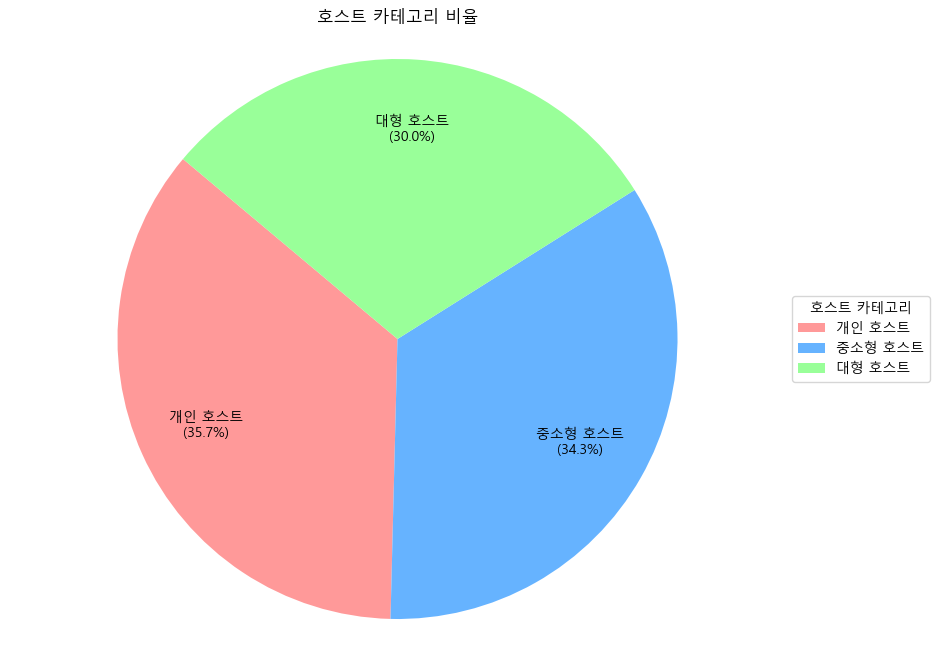

In [5]:
# 개인 호스트, 중소형 호스트, 대형 호스트의 비율 계산
total_hosts = host_category_counts.sum()
host_category_ratios = (host_category_counts / total_hosts) * 100
print(f"\n호스트 카테고리 비율: {host_category_ratios}")

# 파이그래프로 시각화
fig, ax = plt.subplots(figsize=(10, 8))
wedges, texts, autotexts = ax.pie(host_category_counts, autopct='%1.1f%%', startangle=140, pctdistance=0.75, colors= ['#ff9999','#66b3ff','#99ff99'])
# 파이 안에 "이름+비율" 표시
for i, a in enumerate(autotexts):
    label = host_category_counts.index[i]
    current_pct = a.get_text()
    a.set_text(f"{label}\n({current_pct})")
    a.set_fontsize(10)
    a.set_color('black')
# 범례 추가
ax.legend(wedges, host_category_counts.index, title="호스트 카테고리", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))
plt.title('호스트 카테고리 비율')
plt.axis('equal')  # 원이 둥글게 보이도록 설정
plt.show()

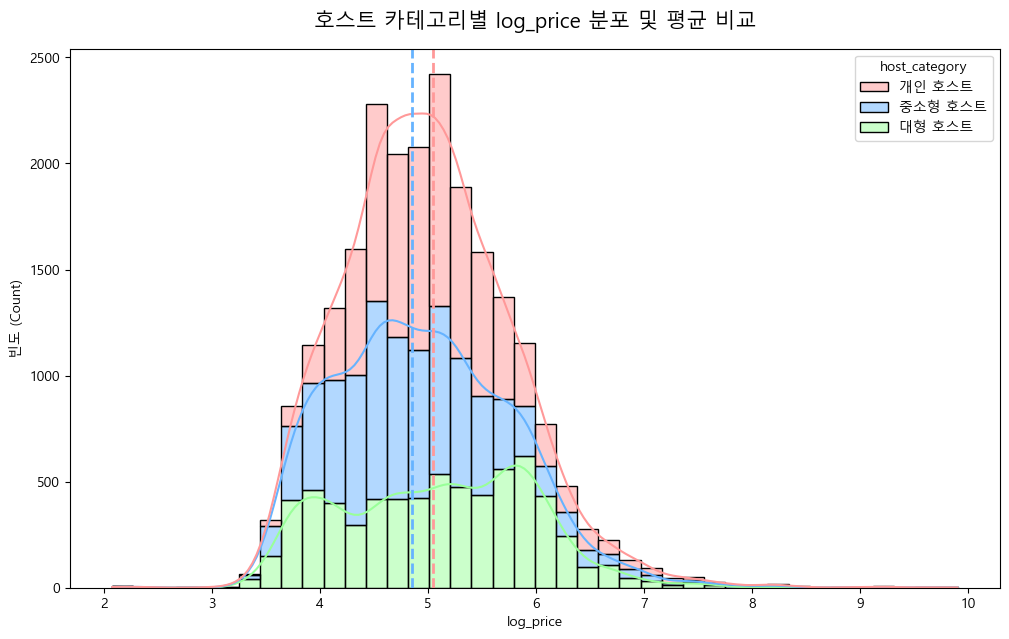

In [6]:
# 호스트 카테고리별 log_price 분포 시각화
plt.figure(figsize=(12, 7))
sns.histplot(data=df_cleaned_copy, x='log_price', hue='host_category', 
             multiple='stack', kde=True, bins=40, 
             palette=['#ff9999','#66b3ff','#99ff99'], alpha=0.5)

# 각 카테고리별 평균값 계산 및 수직선(axvline) 추가
colors = ['#ff9999','#66b3ff','#99ff99']
categories = ['개인 호스트', '중소형 호스트', '기업형 호스트'] 

for i, cat in enumerate(categories):
    host_mean_val = df_cleaned_copy[df_cleaned_copy['host_category'] == cat]['log_price'].mean()
    
    # 수직선 그리기
    plt.axvline(host_mean_val, color=colors[i], linestyle='--', linewidth=2)

# 4. 라벨 및 타이틀 설정
plt.title('호스트 카테고리별 log_price 분포 및 평균 비교', fontsize=15, pad=15)
plt.xlabel('log_price')
plt.ylabel('빈도 (Count)')

plt.show()

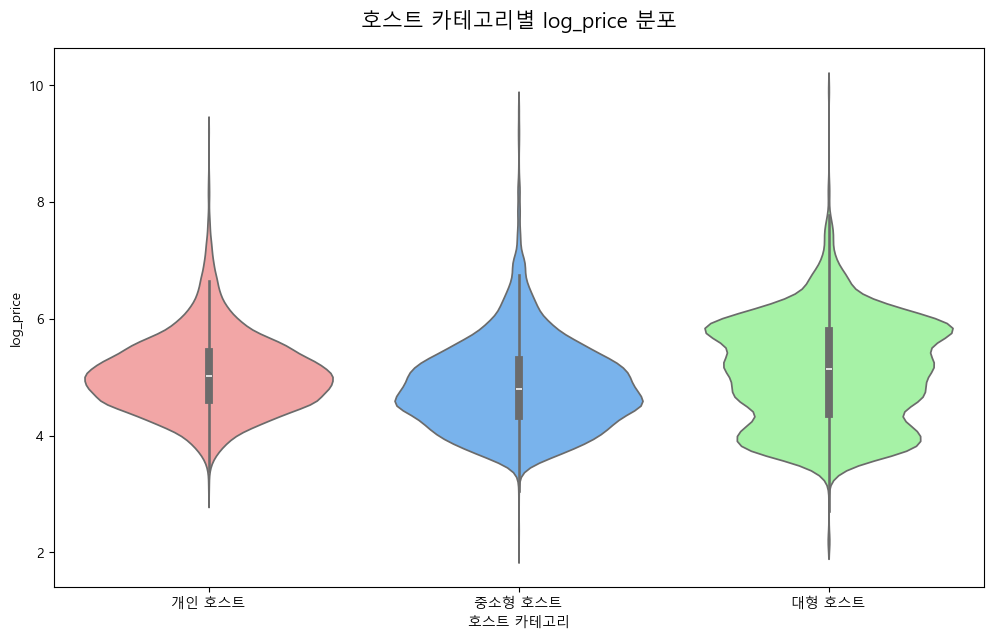

In [7]:
#바이올렛 도표로 시각화
plt.figure(figsize=(12, 7))
sns.violinplot(data=df_cleaned_copy, x='host_category', y='log_price', palette=['#ff9999','#66b3ff','#99ff99'])
plt.title('호스트 카테고리별 log_price 분포', fontsize=15, pad=15)
plt.xlabel('호스트 카테고리')
plt.ylabel('log_price')
plt.show()

In [8]:
# 호스트 카테고리별 에어비앤비 비노출/노출 호스트 숙소 분포 시각화
 # 개인 호스트/중소형 호스트/기업형 호스트의 비노출/노출 숙소 분포 시각화

# 에어비앤비 비노출 호스트 숙소 분포 확인
 # host_total_listings_count: 호스트가 보유한 총 숙소 수
 # host_listings_count: 호스트가 보유한 노출 숙소 수
# 비노출 숙소 개수 컬럼 생성
# host_non_exposure = host_total_listings_count - host_listings_count
df_cleaned_copy['host_non_exposure'] = df_cleaned_copy['host_total_listings_count'] - df_cleaned_copy['host_listings_count']
 # No: 비노출 숙소가 있는 호스트, Yes: 비노출 숙소가 없는 호스트
df_cleaned_copy['has_non_exposure'] = df_cleaned_copy['host_non_exposure'].apply(lambda x: 'No' if x > 0 else 'Yes')
df_cleaned_copy['has_non_exposure'].value_counts()

has_non_exposure
No     14144
Yes     8164
Name: count, dtype: int64

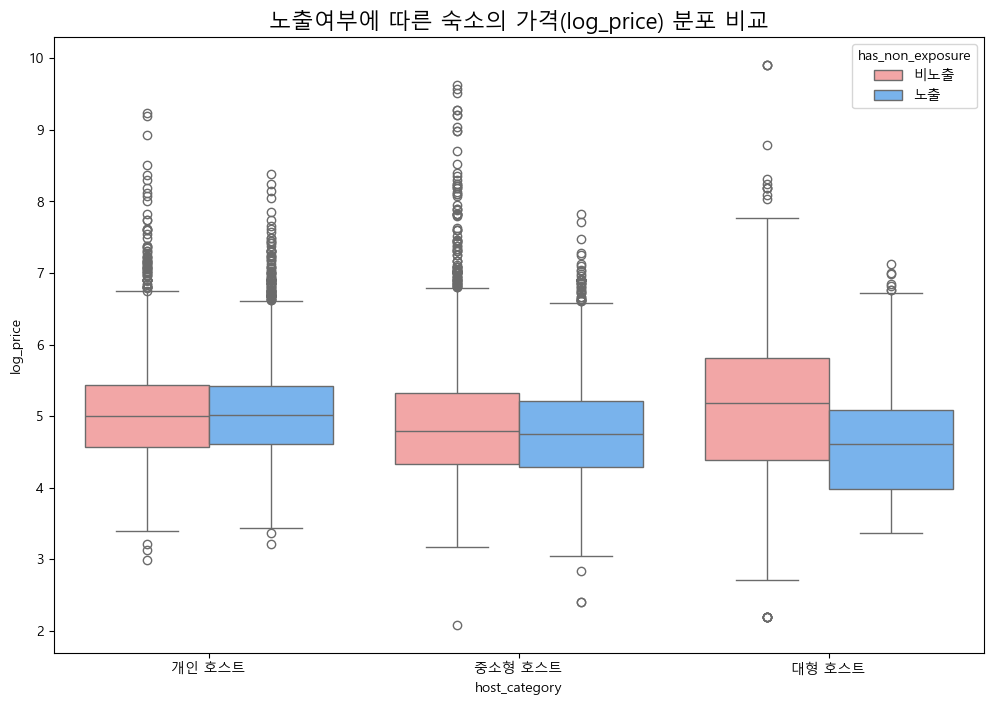

In [9]:
# 호스트 카테고리별 에어비앤비 비노출/노출 호스트 숙소 분포 시각화
 # 개인 호스트/중소형 호스트/기업형 호스트의 비노출/노출 숙소 분포 시각화

# 에어비앤비 비노출 호스트 숙소 분포 확인
 # host_total_listings_count: 호스트가 보유한 총 숙소 수
 # host_listings_count: 호스트가 보유한 노출 숙소 수
# 비노출 숙소 개수 컬럼 생성
df_cleaned_copy['has_non_exposure'] = df_cleaned_copy['host_non_exposure'].apply(lambda x: '비노출' if x > 0 else '노출')

# 비노출 숙소 유무에 따른 가격 분포 시각화
plt.figure(figsize=(12, 8))
sns.boxplot(
    data=df_cleaned_copy, 
    x='host_category', 
    y='log_price', 
    hue='has_non_exposure', # '개수'가 아닌 '유무'로 비교
    palette=['#ff9999', '#66b3ff']
)

plt.title('노출여부에 따른 숙소의 가격(log_price) 분포 비교', fontsize=16)
plt.show()

In [35]:
# 분석에 사용할 데이터 그룹 만들기 (NaN 제거 포함)
groups = []
labels = []

# 카테고리와 노출여부의 모든 조합을 돌며 데이터를 나눕니다.
for cat in ['개인 호스트', '중소형 호스트']: # 기업형은 0개이므로 제외
    for exposure in ['노출', '비노출']:
        # 해당 조건에 맞는 log_price 데이터만 추출
        data = df_cleaned_copy[
            (df_cleaned_copy['host_category'] == cat) & 
            (df_cleaned_copy['has_non_exposure'] == exposure)
        ]['log_price'].dropna()
        
        if len(data) > 0:
            groups.append(data)
            labels.append(f"{cat}_{exposure}")
# 1. 정규성 확인 함수 정의 (위에서 작성하신 코드)
def check_normality_simple(data, name="데이터"):
    if pd.isna(data).any():
        data = data.dropna()
    
    n = len(data)
    print(f"\n[{name} 정규성 검정] n={n}")
    print("-" * 40)
    
    skew = stats.skew(data)
    kurt = stats.kurtosis(data, fisher=True)
    print(f"왜도(Skewness): {skew:.3f}")
    print(f"첨도(Kurtosis): {kurt:.3f}")
    
    if n < 30:
        stat, p = shapiro(data)
        is_normal = p > 0.05
        reason = f"Shapiro p={'>' if is_normal else '≤'}0.05"
    elif n < 100:
        if abs(skew) < 1 and abs(kurt) < 2:
            is_normal = True
            reason = "|왜도|<1, |첨도|<2"
        else:
            stat, p = shapiro(data)
            is_normal = p > 0.05
            reason = f"Shapiro p={'>' if is_normal else '≤'}0.05"
    else:
        # 데이터가 많을 때 (에어비앤비 데이터는 보통 여기 해당)
        is_normal = abs(skew) < 2
        reason = f"|왜도|{'<' if is_normal else '≥'}2 (중심극한정리)"
    
    print(f"결과: {'정규분포 가정 충족' if is_normal else '정규분포 가정 위반'} ({reason})")
    return is_normal

# 2. 가설 설정 출력
print("\n[가설 설정]")
print("H0: 호스트 종류 및 노출 여부별 평균 숙소 가격이 같다.")
print("H1: 적어도 한 그룹의 평균 숙소 가격이 다르다.")
print("유의수준: α = 0.05")

# 3. 데이터 그룹화 및 검정 실행
normality_results = []
all_normal = True

# 분석할 그룹 조합 (기업형은 데이터가 없으므로 제외)
categories = ['개인 호스트', '중소형 호스트']
exposures = ['노출', '비노출']

print("\n" + "="*60)
print("Step 1: 그룹별 정규성 검정 실행")
print("="*60)

for cat in categories:
    for exp in exposures:
        label = f"{cat}_{exp}"
        # 해당되는 데이터 추출
        target_data = df_cleaned_copy[
            (df_cleaned_copy['host_category'] == cat) & 
            (df_cleaned_copy['has_non_exposure'] == exp)
        ]['log_price'].dropna()
        
        if len(target_data) > 0:
            # 함수 호출
            is_normal = check_normality_simple(target_data, label)
            all_normal = all_normal and is_normal
            
            # 결과 저장
            normality_results.append({
                '그룹': label,
                'n': len(target_data),
                '왜도': round(stats.skew(target_data), 3),
                '첨도': round(stats.kurtosis(target_data, fisher=True), 3),
                '판정': '정규분포 충족' if is_normal else '정규분포 위반'
            })

# 4. 요약 테이블 출력
result_df = pd.DataFrame(normality_results)
print("\n[정규성 검정 최종 요약]")
print(result_df)

if all_normal:
    print("\n✅ 모든 그룹이 정규성을 만족합니다. -> ANOVA 사용 가능")
else:
    print("\n❌ 일부 그룹이 정규성을 위반했습니다. -> 비모수 검정(Mann-Whitney 등) 권장")


[가설 설정]
H0: 호스트 종류 및 노출 여부별 평균 숙소 가격이 같다.
H1: 적어도 한 그룹의 평균 숙소 가격이 다르다.
유의수준: α = 0.05

Step 1: 그룹별 정규성 검정 실행

[개인 호스트_노출 정규성 검정] n=4547
----------------------------------------
왜도(Skewness): 0.748
첨도(Kurtosis): 1.424
결과: 정규분포 가정 충족 (|왜도|<2 (중심극한정리))

[개인 호스트_비노출 정규성 검정] n=3420
----------------------------------------
왜도(Skewness): 0.867
첨도(Kurtosis): 2.121
결과: 정규분포 가정 충족 (|왜도|<2 (중심극한정리))

[중소형 호스트_노출 정규성 검정] n=3185
----------------------------------------
왜도(Skewness): 0.553
첨도(Kurtosis): 0.417
결과: 정규분포 가정 충족 (|왜도|<2 (중심극한정리))

[중소형 호스트_비노출 정규성 검정] n=4473
----------------------------------------
왜도(Skewness): 1.100
첨도(Kurtosis): 2.932
결과: 정규분포 가정 충족 (|왜도|<2 (중심극한정리))

[정규성 검정 최종 요약]
            그룹     n     왜도     첨도       판정
0    개인 호스트_노출  4547  0.748  1.424  정규분포 충족
1   개인 호스트_비노출  3420  0.867  2.121  정규분포 충족
2   중소형 호스트_노출  3185  0.553  0.417  정규분포 충족
3  중소형 호스트_비노출  4473  1.100  2.932  정규분포 충족

✅ 모든 그룹이 정규성을 만족합니다. -> ANOVA 사용 가능


In [25]:
# ==========================================================================
# Two-way ANOVA (정규성 충족, 등분산성 충족)
# ==========================================================================
print("\n" + "="*60)
print("Step 3: Two-way ANOVA 자동 검정")
print("="*60)

if all_normal and equal_var_anova:
    # ---------------------------------------------------------
    # 1. 표준 ANOVA (모든 조건 만족 시)
    # ---------------------------------------------------------
    print("\n[표준 Two-way ANOVA 수행]")
    # 보내주신 그 코드를 그대로 사용합니다!
    model = ols('log_price ~ host_category * has_non_exposure', data=df_cleaned_copy).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    
    # 효과 크기(지분율) 계산 추가
    ss_total = anova_table['sum_sq'].sum()
    anova_table['eta_sq'] = anova_table['sum_sq'] / ss_total
    print(anova_table)

elif all_normal and not equal_var_anova:
    # ---------------------------------------------------------
    # 2. Welch's ANOVA (등분산성 위반 시 - 안경 쓰고 보기)
    # ---------------------------------------------------------
    print("\n[Welch's Two-way ANOVA 수행]")
    # pingouin 라이브러리는 등분산성이 깨졌을 때 아주 똑똑하게 계산해줍니다.
    res = pg.anova(dv='log_price', between=['host_category', 'has_non_exposure'], data=df_cleaned_copy)
    print(res[['Source', 'SS', 'DF', 'F', 'p-unc', 'np2']])

else:
    # ---------------------------------------------------------
    # 3. 비모수 검정 (정규성 위반 시 - 순위로 계산하기)
    # ---------------------------------------------------------
    print("\n[Kruskal-Wallis 비모수 검정 수행]")
    # 이원 분석의 비모수 버전은 '팀을 합쳐서' 순위를 매깁니다.
    df_cleaned_copy['combined_group'] = df_cleaned_copy['host_category'] + "_" + df_cleaned_copy['has_non_exposure']
    h_stat, p_kw = stats.kruskal(*[group["log_price"].values for name, group in df_cleaned_copy.groupby("combined_group")])
    print(f"H-통계량: {h_stat:.4f}, p-value: {p_kw}")


Step 3: Two-way ANOVA 자동 검정

[Kruskal-Wallis 비모수 검정 수행]
H-통계량: 660.5248, p-value: 1.680696615089698e-140


In [20]:
# 사후분석 진행 (Dunn's test) - 어떤 그룹끼리 진짜 차이가 나는지 확인
import scikit_posthocs as sp

posthoc = sp.posthoc_dunn(df_cleaned_copy, val_col='log_price', group_col='combined_group', p_adjust='bonferroni')
print(posthoc)

                개인 호스트_노출    개인 호스트_비노출     대형 호스트_노출    대형 호스트_비노출  \
개인 호스트_노출    1.000000e+00  1.000000e+00  6.667133e-26  9.545502e-03   
개인 호스트_비노출   1.000000e+00  1.000000e+00  9.581693e-22  9.775141e-06   
대형 호스트_노출    6.667133e-26  9.581693e-22  1.000000e+00  2.697029e-33   
대형 호스트_비노출   9.545502e-03  9.775141e-06  2.697029e-33  1.000000e+00   
중소형 호스트_노출   1.264283e-54  1.883171e-38  7.248419e-03  9.725857e-86   
중소형 호스트_비노출  2.147644e-35  2.733252e-22  6.051516e-07  1.694230e-63   

               중소형 호스트_노출   중소형 호스트_비노출  
개인 호스트_노출    1.264283e-54  2.147644e-35  
개인 호스트_비노출   1.883171e-38  2.733252e-22  
대형 호스트_노출    7.248419e-03  6.051516e-07  
대형 호스트_비노출   9.725857e-86  1.694230e-63  
중소형 호스트_노출   1.000000e+00  3.812019e-04  
중소형 호스트_비노출  3.812019e-04  1.000000e+00  


# 다음 분석 내용은..?
calculated_host_listings_count_entire_homes => 독채/아파트
calculated_host_listings_count_private_rooms => 개인실 수(거실/화장실 공유)
calculated_host_listings_count_shared_rooms => 다인실 수(게스트 하우스)

=>  1) 가격 
    2) 평점 

In [ ]:
# calculated_host_listings_count_entire_homes, calculated_host_listings_count_private_rooms, calculated_host_listings_count_shared_rooms의 가격측면에서의 차이 분석
entire_homes = df_cleaned_copy[df_cleaned_copy['calculated_host_listings_count_entire_homes'] > 0]['price']
private_rooms = df_cleaned_copy[df_cleaned_copy['calculated_host_listings_count_private_rooms'] > 0]['price']
shared_rooms = df_cleaned_copy[df_cleaned_copy['calculated_host_listings_count_shared_rooms'] > 0]['price']

# 히트맵을 통한 상관관계 분석
plt.figure(figsize=(10, 8))
sns.heatmap(df_cleaned_copy[['price', 'calculated_host_listings_count_entire_homes', 'calculated_host_listings_count_private_rooms', 'calculated_host_listings_count_shared_rooms']].corr(), annot=True, cmap='coolwarm')
plt.title('price와 숙소 유형별 호스트 숙소 수 간의 상관관계', fontsize=16)
plt.show()